#### [HOME](../README.md) | [NEXT](2.OOP_Multi_Feature_Linear_Regression.ipynb)

---

# OOP Linear Regression Implementation

This Jupyter Notebook provides a basic implementation of Single Feature Linear Regression. The data set contains measurements on a single species of insect captured on two continents. We want to predict an male insects latitude given the wingspan.

#### Step 1 - Import Dependencies

In [2]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error 

#### Step 2 - Import, Filter and Visualise The Data

In [19]:
#Import data as a Pandas DataFrame
flowers = pd.read_csv('./data/Iris.csv', sep=',')
flowers = pd.DataFrame({
    'sepal length': flowers['SepalLengthCm'],
    'sepal width': flowers['SepalWidthCm'],
    'petal length': flowers['PetalLengthCm'],
    'petal width': flowers['PetalWidthCm'],
    'class': flowers['Species']
})

# Filter the data to only male insects
# insects = insects[insects.sex == 1]

# Features variable
X_flowers = flowers[['petal length']]
# Target variable
y_flowers = flowers['petal width']

flowers.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


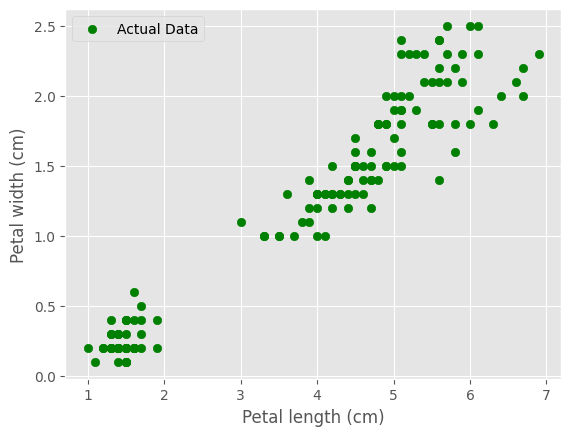

In [7]:
#Plot the data
plt.scatter(X_flowers, y_flowers, label="Actual Data", color='g')
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend()
plt.show()

#### Step 3: Instantiate a LinearRegression Object

In [15]:
flowers_regression = LinearRegression()

#### Step 4: Fit the model

In [16]:
flowers_regression.fit(X_flowers, y_flowers)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.42]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['petal length']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.3665
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


#### Step 5: Predict Values

In [17]:
# Predict the target for the whole dataset
latitude_predictions = flowers_regression.predict(X_flowers)

#Predict the target for a new data point
new_flower = pd.DataFrame({
    'petal length': [5.0]
})
new_flower['petal width'] = flowers_regression.predict(new_flower)
print(f"New flower is:\n{new_flower}")

New flower is:
   petal length  petal width
0           5.0     1.715582


#### Step 6: Plot the Predictions

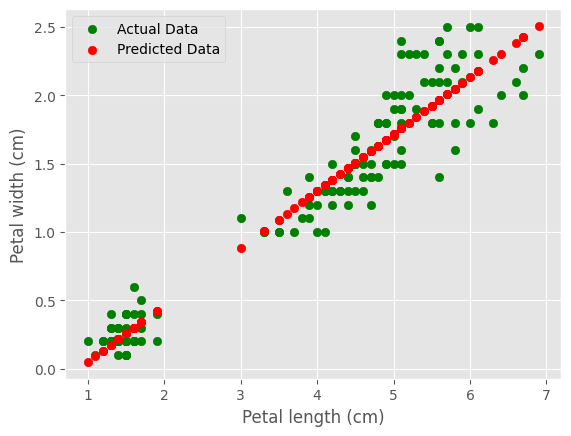

In [18]:
#Plot the predictions compared to the actual data
plt.scatter(X_flowers, y_flowers, label="Actual Data", color='g')
plt.scatter(X_flowers, latitude_predictions, label="Predicted Data", c='r')
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend()
plt.show()

#### Step 7: Evaluate The Model

In [22]:
#Get Evalutative Data from the model
print(f"Model coefficient :{flowers_regression.coef_}")
print(f"Model y intercept :{flowers_regression.intercept_}")
print(f"Model score :{flowers_regression.score(X_flowers,y_flowers)}")
mae = mean_absolute_error(y_true=y_flowers,y_pred=latitude_predictions) 
mse = mean_squared_error(y_true=y_flowers,y_pred=latitude_predictions)
# mae=mean absolute error)
print("MAE:",mae)

# mse=mean squared error
print("MSE:",mse)

Model coefficient :[0.41641913]
Model y intercept :-0.3665140452167275
Model score :0.9269012279220037
MAE: 0.1572565947049201
MSE: 0.04228994631948424


In [21]:
#Optional: Manually Evaluate the loss and cost of the model
model_loss = pd.DataFrame({
    'Target': y_flowers,
    'Predicted result': latitude_predictions,
    'Loss': abs(flowers_regression.predict(X_flowers).round(2) - y_flowers)**2
})
model_cost = 1 / (2 * model_loss.shape[0]) * model_loss['Loss'].sum()

print(f"The cost of this model is {model_cost:.5f}")
print(model_loss)

The cost of this model is 0.02114
     Target  Predicted result    Loss
0       0.2          0.216473  0.0004
1       0.2          0.216473  0.0004
2       0.2          0.174831  0.0009
3       0.2          0.258115  0.0036
4       0.2          0.216473  0.0004
..      ...               ...     ...
145     2.3          1.798865  0.2500
146     1.9          1.715582  0.0324
147     2.0          1.798865  0.0400
148     2.3          1.882149  0.1764
149     1.8          1.757224  0.0016

[150 rows x 3 columns]
